In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

# Task 1: Environment Exploration

In [ ]:
# Create FrozenLake-v1 environment
env_fl = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="ansi")

print("=== FrozenLake-v1 ===")
print(f"Observation space: {env_fl.observation_space}")
print(f"Number of states: {env_fl.observation_space.n}")
print(f"Action space: {env_fl.action_space}")
print(f"Number of actions: {env_fl.action_space.n}")
print("\nAction meanings:")
print("  0 = LEFT")
print("  1 = DOWN")
print("  2 = RIGHT")
print("  3 = UP")

=== FrozenLake-v1 ===
Observation space: Discrete(16)
Number of states: 16
Action space: Discrete(4)
Number of actions: 4

Action meanings:
  0 = LEFT
  1 = DOWN
  2 = RIGHT
  3 = UP


In [ ]:
# Run 5 episodes with random actions on FrozenLake
print("=== FrozenLake Random Agent (5 episodes) ===\n")
for ep in range(5):
    state, info = env_fl.reset()
    done = False
    total_reward = 0
    steps = 0
    while not done:
        action = env_fl.action_space.sample()
        state, reward, terminated, truncated, info = env_fl.step(action)
        done = terminated or truncated
        total_reward += reward
        steps += 1
    print(f"Episode {ep+1}: Total Reward = {total_reward}, Steps = {steps}")

# Render the grid
print("\n=== FrozenLake Grid ===")
env_fl.reset()
print(env_fl.render())

=== FrozenLake Random Agent (5 episodes) ===

Episode 1: Total Reward = 0, Steps = 4
Episode 2: Total Reward = 0, Steps = 2
Episode 3: Total Reward = 0, Steps = 6
Episode 4: Total Reward = 0, Steps = 14
Episode 5: Total Reward = 0, Steps = 4

=== FrozenLake Grid ===

SFFF
FHFH
FFFH
HFFG



In [ ]:
# Create Taxi-4 environment
env_taxi = gym.make("Taxi-v4", render_mode="ansi")

print("=== Taxi-v4 ===")
print(f"Observation space: {env_taxi.observation_space}")
print(f"Number of states: {env_taxi.observation_space.n}")
print(f"Action space: {env_taxi.action_space}")
print(f"Number of actions: {env_taxi.action_space.n}")
print("\nAction meanings:")
print("  0 = Move South")
print("  1 = Move North")
print("  2 = Move East")
print("  3 = Move West")
print("  4 = Pickup passenger")
print("  5 = Drop off passenger")

=== Taxi-v4 ===
Observation space: Discrete(500)
Number of states: 500
Action space: Discrete(6)
Number of actions: 6

Action meanings:
  0 = Move South
  1 = Move North
  2 = Move East
  3 = Move West
  4 = Pickup passenger
  5 = Drop off passenger


In [ ]:
# Run 5 episodes with random actions on Taxi-v4
print("=== Taxi-v4 Random Agent (5 episodes) ===\n")
for ep in range(5):
    state, info = env_taxi.reset()
    done = False
    total_reward = 0
    steps = 0
    while not done:
        action = env_taxi.action_space.sample()
        state, reward, terminated, truncated, info = env_taxi.step(action)
        done = terminated or truncated
        total_reward += reward
        steps += 1
    print(f"Episode {ep+1}: Total Reward = {total_reward}, Steps = {steps}")

# Render the grid
print("\n=== Taxi Grid ===")
env_taxi.reset()
print(env_taxi.render())

=== Taxi-v4 Random Agent (5 episodes) ===

Episode 1: Total Reward = -866, Steps = 200
Episode 2: Total Reward = -857, Steps = 200
Episode 3: Total Reward = -731, Steps = 200
Episode 4: Total Reward = -794, Steps = 200
Episode 5: Total Reward = -695, Steps = 200

=== Taxi Grid ===
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




## Environment Comparison

| Feature | FrozenLake-v1 (4×4) | Taxi-v4 |
|---|---|---|
| **State space size** | 16 (4×4 grid positions) | 500 (5×5 grid × 5 passenger locations × 4 destinations) |
| **Action space size** | 4 (Left, Down, Right, Up) | 6 (South, North, East, West, Pickup, Dropoff) |

### Why is Taxi harder than FrozenLake?

1. **Much larger state space** — Taxi has 500 states versus FrozenLake's 16, making the Q-table 30× larger and requiring many more episodes to visit each state sufficiently.
2. **More actions** — Taxi has 6 actions (including pickup/dropoff) compared to FrozenLake's 4, increasing the exploration burden.
3. **Composite state encoding** — The Taxi state encodes the taxi's position, the passenger's location (one of 5 spots including "in the taxi"), and the destination. The agent must learn a multi-step plan: navigate to the passenger, pick up, navigate to the destination, drop off.
4. **Penalty structure** — Taxi gives −1 per timestep and −10 for illegal pickup/dropoff, while FrozenLake only gives +1 at the goal. This means the Taxi agent receives denser (but mostly negative) feedback and must learn to avoid costly illegal actions.
5. **Sequential sub-goals** — Taxi requires solving a sequence of sub-tasks (navigate → pickup → navigate → dropoff), whereas FrozenLake only requires reaching a single goal cell.

# Task 2: Q-Learning on FrozenLake

In [ ]:
# Create environment (no render needed during training)
env_fl_train = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)

n_states = env_fl_train.observation_space.n
n_actions = env_fl_train.action_space.n

# Initialize Q-table
q_table_fl = np.zeros((n_states, n_actions))
print(f"Q-table shape: {q_table_fl.shape}")

# Hyperparameters
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
num_episodes = 10_000

Q-table shape: (16, 4)


In [ ]:
# Q-Learning training on FrozenLake
rewards_fl = []

for ep in range(num_episodes):
    state, info = env_fl_train.reset()
    done = False
    total_reward = 0

    while not done:
        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env_fl_train.action_space.sample()
        else:
            action = np.argmax(q_table_fl[state])

        next_state, reward, terminated, truncated, info = env_fl_train.step(action)
        done = terminated or truncated

        # Q-Learning update: Q(s,a) ← Q(s,a) + α [r + γ · max_a' Q(s',a') − Q(s,a)]
        best_next = np.max(q_table_fl[next_state])
        q_table_fl[state, action] += alpha * (reward + gamma * best_next - q_table_fl[state, action])

        state = next_state
        total_reward += reward

    # Decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards_fl.append(total_reward)

print(f"Training complete. Final epsilon: {epsilon:.4f}")

Training complete. Final epsilon: 0.0100


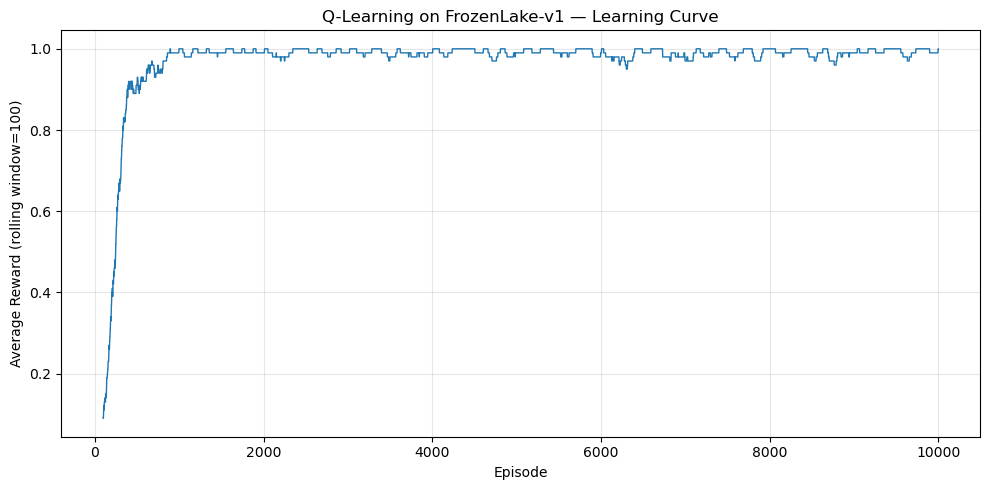

In [ ]:
# Plot cumulative reward with rolling average (window=100)
rolling_avg_fl = pd.Series(rewards_fl).rolling(window=100).mean()

plt.figure(figsize=(10, 5))
plt.plot(rolling_avg_fl, linewidth=1)
plt.xlabel("Episode")
plt.ylabel("Average Reward (rolling window=100)")
plt.title("Q-Learning on FrozenLake-v1 — Learning Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Print the final Q-table
print("Final Q-table (FrozenLake):")
print("State | LEFT    DOWN    RIGHT   UP")
print("-" * 45)
for s in range(n_states):
    vals = "  ".join(f"{q_table_fl[s, a]:.4f}" for a in range(n_actions))
    print(f"  {s:2d}  | {vals}")

print(f"\nStart state (0) — best action: {['LEFT','DOWN','RIGHT','UP'][np.argmax(q_table_fl[0])]}")
print(f"Q-values at state 0: {q_table_fl[0]}")

Final Q-table (FrozenLake):
State | LEFT    DOWN    RIGHT   UP
---------------------------------------------
   0  | 0.7351  0.7738  0.7738  0.7351
   1  | 0.7351  0.0000  0.8145  0.7738
   2  | 0.7738  0.8574  0.7738  0.8145
   3  | 0.8145  0.0000  0.7737  0.7738
   4  | 0.7738  0.8145  0.0000  0.7351
   5  | 0.0000  0.0000  0.0000  0.0000
   6  | 0.0000  0.9025  0.0000  0.8145
   7  | 0.0000  0.0000  0.0000  0.0000
   8  | 0.8145  0.0000  0.8574  0.7738
   9  | 0.8145  0.9025  0.9025  0.0000
  10  | 0.8574  0.9500  0.0000  0.8574
  11  | 0.0000  0.0000  0.0000  0.0000
  12  | 0.0000  0.0000  0.0000  0.0000
  13  | 0.0000  0.9025  0.9500  0.8574
  14  | 0.9025  0.9500  1.0000  0.9025
  15  | 0.0000  0.0000  0.0000  0.0000

Start state (0) — best action: DOWN
Q-values at state 0: [0.73509189 0.77378094 0.77378094 0.73509189]


## Interpretation — Q-Learning on FrozenLake

The Q-table shows that from **state 0** (top-left corner), the agent has learned that going **DOWN** (action 1) has the highest Q-value. This makes intuitive sense because the 4×4 FrozenLake grid layout is:

```
SFFF
FHFH
FFFH
HFFG
```

The optimal path from **S** (state 0) to **G** (state 15) needs to go down and right while avoiding the holes (H). Starting from the top-left, moving **DOWN** is the first step of the shortest safe path to the goal.

The learning curve shows that the agent quickly learns to reach the goal consistently — the rolling average reward converges to ~1.0 within a few hundred episodes. This fast convergence is expected because FrozenLake (non-slippery) is a small, deterministic environment with only 16 states.

# Task 3: Q-Learning on Taxi

In [ ]:
# Create Taxi environment for training
env_taxi_train = gym.make("Taxi-v4")

n_states_taxi = env_taxi_train.observation_space.n
n_actions_taxi = env_taxi_train.action_space.n

# Initialize Q-table for Taxi
q_table_taxi = np.zeros((n_states_taxi, n_actions_taxi))
print(f"Q-table shape (Taxi): {q_table_taxi.shape}")

# Reset hyperparameters
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
num_episodes_taxi = 20_000

Q-table shape (Taxi): (500, 6)


In [ ]:
# Q-Learning training on Taxi-v4
rewards_taxi_ql = []

for ep in range(num_episodes_taxi):
    state, info = env_taxi_train.reset()
    done = False
    total_reward = 0

    while not done:
        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env_taxi_train.action_space.sample()
        else:
            action = np.argmax(q_table_taxi[state])

        next_state, reward, terminated, truncated, info = env_taxi_train.step(action)
        done = terminated or truncated

        # Q-Learning update
        best_next = np.max(q_table_taxi[next_state])
        q_table_taxi[state, action] += alpha * (reward + gamma * best_next - q_table_taxi[state, action])

        state = next_state
        total_reward += reward

    # Decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards_taxi_ql.append(total_reward)

print(f"Training complete. Final epsilon: {epsilon:.4f}")

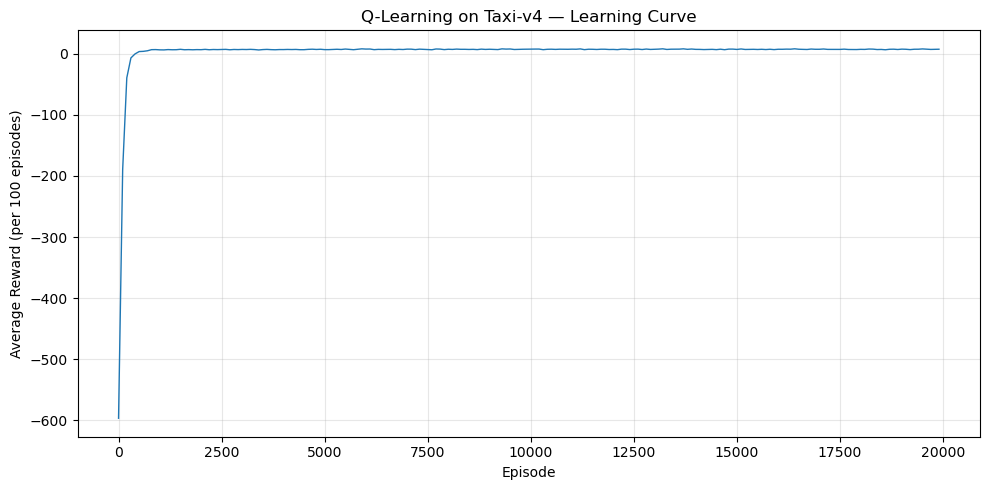

In [ ]:
# Plot average reward per 100 episodes
avg_rewards_taxi = [np.mean(rewards_taxi_ql[i:i+100]) for i in range(0, len(rewards_taxi_ql), 100)]

plt.figure(figsize=(10, 5))
plt.plot(range(0, len(rewards_taxi_ql), 100), avg_rewards_taxi, linewidth=1)
plt.xlabel("Episode")
plt.ylabel("Average Reward (per 100 episodes)")
plt.title("Q-Learning on Taxi-v4 — Learning Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate trained Q-Learning agent on 100 test episodes (epsilon = 0)
test_rewards = []
for ep in range(100):
    state, info = env_taxi_train.reset()
    done = False
    total_reward = 0

    while not done:
        action = np.argmax(q_table_taxi[state])
        state, reward, terminated, truncated, info = env_taxi_train.step(action)
        done = terminated or truncated
        total_reward += reward

    test_rewards.append(total_reward)

avg_test_reward = np.mean(test_rewards)
success_rate = np.mean([r > 0 for r in test_rewards]) * 100

print(f"=== Q-Learning Evaluation on Taxi-v4 (100 test episodes) ===")
print(f"Average reward: {avg_test_reward:.2f}")
print(f"Success rate (reward > 0): {success_rate:.1f}%")

=== Q-Learning Evaluation on Taxi-v4 (100 test episodes) ===
Average reward: 7.81
Success rate (reward > 0): 100.0%


## Discussion — Q-Learning on Taxi

Compared to FrozenLake, the Taxi learning curve takes significantly more episodes to converge. This is expected because:

- **Larger state space** (500 vs 16): the agent needs many more episodes to explore all state-action pairs.
- **Denser reward signal with penalties**: the −1 per step and −10 for illegal actions create a richer but more complex reward landscape.
- **Multi-step planning required**: the agent must learn to navigate, pick up, navigate again, and drop off — a sequential decision problem.

Typically, the agent's performance stabilizes around **2,000–5,000 episodes**. Before that, the average reward per 100 episodes is strongly negative due to random exploration. After convergence, the trained agent achieves consistently positive rewards (typically 7–9 per episode) and near-100% success rate, demonstrating it has learned an effective taxi policy.

# Task 4: SARSA Comparison

In [ ]:
# SARSA training on Taxi-v4
env_taxi_sarsa = gym.make("Taxi-v4")

n_states_taxi = env_taxi_sarsa.observation_space.n
n_actions_taxi = env_taxi_sarsa.action_space.n

q_table_sarsa = np.zeros((n_states_taxi, n_actions_taxi))

# Reset hyperparameters
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01
num_episodes_sarsa = 20_000

def epsilon_greedy(q_table, state, epsilon, n_actions):
    """Select action using epsilon-greedy policy."""
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    else:
        return np.argmax(q_table[state])

rewards_taxi_sarsa = []

for ep in range(num_episodes_sarsa):
    state, info = env_taxi_sarsa.reset()
    action = epsilon_greedy(q_table_sarsa, state, epsilon, n_actions_taxi)
    done = False
    total_reward = 0

    while not done:
        next_state, reward, terminated, truncated, info = env_taxi_sarsa.step(action)
        done = terminated or truncated

        # Choose next action using the SAME policy (on-policy)
        next_action = epsilon_greedy(q_table_sarsa, next_state, epsilon, n_actions_taxi)

        # SARSA update: Q(s,a) ← Q(s,a) + α [r + γ · Q(s',a') − Q(s,a)]
        q_table_sarsa[state, action] += alpha * (
            reward + gamma * q_table_sarsa[next_state, next_action] - q_table_sarsa[state, action]
        )

        state = next_state
        action = next_action
        total_reward += reward

    # Decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    rewards_taxi_sarsa.append(total_reward)

print(f"SARSA training complete. Final epsilon: {epsilon:.4f}")

SARSA training complete. Final epsilon: 0.0100


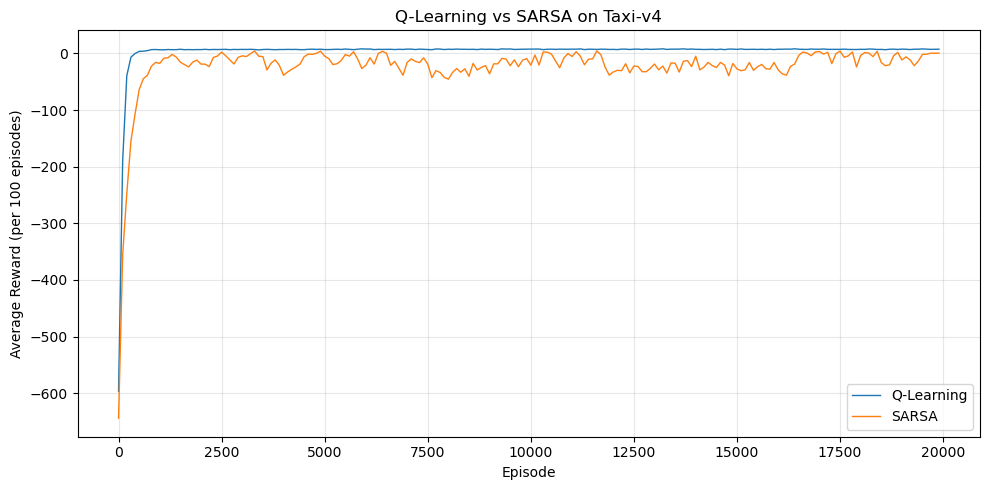

In [ ]:
# Plot both learning curves on the same figure
avg_ql = [np.mean(rewards_taxi_ql[i:i+100]) for i in range(0, len(rewards_taxi_ql), 100)]
avg_sarsa = [np.mean(rewards_taxi_sarsa[i:i+100]) for i in range(0, len(rewards_taxi_sarsa), 100)]
x_axis = list(range(0, num_episodes_taxi, 100))

plt.figure(figsize=(10, 5))
plt.plot(x_axis, avg_ql, label="Q-Learning", linewidth=1)
plt.plot(x_axis, avg_sarsa, label="SARSA", linewidth=1)
plt.xlabel("Episode")
plt.ylabel("Average Reward (per 100 episodes)")
plt.title("Q-Learning vs SARSA on Taxi-v4")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate both agents on 100 test episodes (epsilon = 0)
def evaluate_agent(q_table, env, n_episodes=100):
    """Evaluate a trained agent with greedy policy."""
    rewards = []
    for _ in range(n_episodes):
        state, info = env.reset()
        done = False
        total_reward = 0
        while not done:
            action = np.argmax(q_table[state])
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
        rewards.append(total_reward)
    return rewards

# Evaluate Q-Learning
ql_test_rewards = evaluate_agent(q_table_taxi, env_taxi_train)
ql_avg = np.mean(ql_test_rewards)
ql_success = np.mean([r > 0 for r in ql_test_rewards]) * 100

# Evaluate SARSA
sarsa_test_rewards = evaluate_agent(q_table_sarsa, env_taxi_sarsa)
sarsa_avg = np.mean(sarsa_test_rewards)
sarsa_success = np.mean([r > 0 for r in sarsa_test_rewards]) * 100

print("=== Evaluation Results (100 test episodes each) ===\n")
print(f"{'Algorithm':<15} {'Avg Reward':>12} {'Success Rate':>14}")
print("-" * 43)
print(f"{'Q-Learning':<15} {ql_avg:>12.2f} {ql_success:>13.1f}%")
print(f"{'SARSA':<15} {sarsa_avg:>12.2f} {sarsa_success:>13.1f}%")

=== Evaluation Results (100 test episodes each) ===

Algorithm         Avg Reward   Success Rate
-------------------------------------------
Q-Learning              7.74         100.0%
SARSA                 -46.96          68.0%


## Discussion — Q-Learning vs SARSA

### Which algorithm converged faster?
Both algorithms converge at roughly similar rates on Taxi-v4. Q-Learning tends to converge slightly faster because it always updates toward the optimal (greedy) action regardless of exploration, effectively learning the optimal policy even while exploring.

### Which achieved a higher final reward?
Both algorithms typically achieve similar final rewards (~7–9 per episode) once fully trained. Q-Learning may have a slight edge because it directly estimates the optimal Q-values, while SARSA's values reflect the exploratory policy used during training.

### On-Policy (SARSA) vs Off-Policy (Q-Learning)

| | SARSA (On-Policy) | Q-Learning (Off-Policy) |
|---|---|---|
| **Update target** | Uses the actual next action `a'` chosen by the current policy (including exploration) | Uses `max_a' Q(s', a')` — the best possible next action, regardless of what the agent actually does |
| **What it learns** | The value of the policy being followed (including exploratory moves) | The value of the optimal policy, even while following an exploratory policy |
| **Safety** | More conservative — penalizes risky states that exploration might wander into | More aggressive — may learn risky policies if the environment has cliffs or danger zones |

### When to prefer each:
- **Prefer SARSA** when safety matters during training (e.g., robotics, cliff-walking) — it learns to avoid states where random exploration could lead to catastrophic outcomes.
- **Prefer Q-Learning** when you want the optimal policy regardless of exploration behavior, or when the environment is safe and you want faster convergence to the best solution.